# MODEL COMPARISONS

**TABLE OF CONTENTS**
1. [Model Performance Comparison](#1-model-performance-comparison)
2. [Main Findings per model-family](#2-main-findings-per-model-family)
3. [Visually Comparing Variant 2](#3-visually-comparing-variant-2-of-each-model)

This notebook's goal is to consolidate the project's regression benchmarking into a single, readable comparison: **which model generalizes best and why, under the same evaluation protocol and preprocessing rules.**

**Evaluation priority:** Every model is evaluated with the same cross-validation strategy. We prioritize RMSE (main objective) and report MAE as a secondary sanity check.  

## 1. Model Performance Comparison 

### Variant 1: All features, target = `price`

| Model Family    | Model Name         | RMSE (CV mean) | MAE (CV mean) | 
|-----------------|--------------------|----------------|---------------|
|Linear           |OLS                 | 4183.29        | 2653.57       |
|Linear           |Ridge               | 4183.26        | 2653.48       | 
|Linear           |Lasso               | 4184.48        | 2650.17       |
|Linear           |ElasticNet          | 4203.50        | 2638.32       | 
|Tree             |Random Forest       | 2262.76        | 1336.10       |
|Tree             |Extra Trees         | 2189.71        | 1294.02       | 
|Boosting         |HistGradientBoosting| 2125.23        | 1275.98       |
|Neural Networks  |MLP                 | 3541.98        | 2196.10       |   
|Ensemble Methods |Weighted Mean       | 2118.70        | 1266.30       |    
|Ensemble Methods |Bagging             | 2253.14        | 1319.01       |
|**Ensemble Methods** |**Stacking**            | **2090.80**        | **1253.30**       |   

### Variant 2: Excluding `previousOwners`, target = `log(price)`

| Model Family    | Model Name         | RMSE (CV mean) | MAE (CV mean) | 
|-----------------|--------------------|----------------|---------------|
|Linear           |ElasticNet          | 3559.76        | 2111.42       | 
|Tree             |Random Forest       | 2376.03        | 1306.84       |
|Tree             |Extra Trees         | 2230.75        | 1283.91       | 
|Boosting         |HistGradientBoosting| 2111.82        | 1235.82       |
|Neural Networks  |MLP                 | 2946.51        | 1709.20       |   
|Ensemble Methods |Weighted Mean       | 2147.60        | 1234.00       |    
|Ensemble Methods |Bagging             | 2398.45        | 1323.93       |
|**Ensemble Methods** |**Stacking**            | **2093.40**        | **1226.60**       |   

### Variant 3: Exclusing `previousOwners` and using `age`instead of `year`, target = `log(price)`

| Model Family    | Model Name         | RMSE (CV mean) | MAE (CV mean) | 
|-----------------|--------------------|----------------|---------------|
|Linear           |ElasticNet          | 3559.71        | 2111.40       | 
|Tree             |Random Forest       | 2374.40        | 1306.25       |
|Tree             |Extra Trees         | 2230.48        | 1284.30       | 
|Boosting         |HistGradientBoosting| 2111.99        | 1233.55       |
|Neural Networks  |MLP                 | 2886.43        | 1702.22       |   
|Ensemble Methods |Weighted Mean       | 2154.32        | 1234.22       |    
|Ensemble Methods |Bagging             | 2398.75        | 1324.04       |
|**Ensemble Methods** |**Stacking**            | **2098.16**        | **1225.83**       |   

### Variant 4: Feature Selection (80%), target = `log(price)`

| Model Family    | Model Name         | RMSE (CV mean) | MAE (CV mean) | 
|-----------------|--------------------|----------------|---------------|
|Linear           |ElasticNet          | 3561.46        | 2111.88       | 
|Tree             |Random Forest       | 2382.92        | 1310.15       |
|Tree             |Extra Trees         | 2228.31        | 1283.82       | 
|Boosting         |HistGradientBoosting| 2113.19        | 1239.19       |
|Neural Networks  |MLP                 | 2868.57        | 1684.72       |   
|Ensemble Methods |Weighted Mean       | 2153.48        | 1237.13       |    
|Ensemble Methods |Bagging             | 2407.13        | 1327.62       |
|**Ensemble Methods** |**Stacking**            | **2110.27**        | **1236.32**       |   

### Variant 5: Feature Engineering, Feature Selection (65%), target = `log(price)`

| Model Family    | Model Name         | RMSE (CV mean) | MAE (CV mean) | 
|-----------------|--------------------|----------------|---------------|
|Linear           |ElasticNet          | 3736.79        | 2204.34       | 
|Tree             |Random Forest       | 2360.28        | 1316.77       |
|Tree             |Extra Trees         | 2251.33        | 1293.58       | 
|Boosting         |HistGradientBoosting| 2138.95        | 1254.96       |
|Neural Networks  |MLP                 | 2863.63        | 1662.01       |   
|Ensemble Methods |Weighted Mean       | 2170.32        | 1251.79       |    
|Ensemble Methods |Bagging             | 2366.55        | 1318.16       |
|**Ensemble Methods** |**Stacking**            | **2117.18**        | **1241.48**       |   

## 2. Main Findings (per model-family)

### 2.1. Linear (OLS, Ridge, Lasso, ElasticNet)

- **Best performing model:** ElasticNet

- **Strengths:** stable baseline; fast to tune.

- **Main RMSE driver:** `log1p(price)` and removing `previousOwners` improved RMSE, since the error grew with price (heteroskedasticity).

- **Limitation:** cannot naturally capture non-linear interactions like (brand × model × engineSize) without explicit feature engineering.

Linear models improved when using `log1p(price)` and a compact feature set, but plateaued because the remaining error is dominated by non-linear interactions and conditional effects across brand/model segments.

### 2.2. Bagging Trees (RandomForest, ExtraTrees)

- **Best performing model:** ExtraTrees

- **Strengths:** captures non-linearities and interactions without manual feature crosses.

- **Main RMSE driver:** best RMSE value came from controlling variance via min_samples_leaf, max_depth, and max_features; more aggressive FE/FS did not improve RMSE for our setup.

- **Limitation:** very low train error with noticeably worse CV RMSE/MAE (overfit).

Tree-based models favored the raw target and minimal feature manipulation, but required strong regularization to try and avoid overfitting.

### 2.3. Boosting (HistGradientBoosting)

- **Strengths:** handles complex structure with better bias/variance control than most models.

- **Main RMSE driver:** similarly to what happened with the linear models, the main driver for HGB's performance is log-transformation of the target and removing the variable `previousOwners`.

- **Limitation:** HGB can swing from underfit to overfit depending on the `learning_rate` × `max_iter` tradeoff and structural constraints (`max_depth`, `min_samples_leaf`, etc.).

Removing `previousOwners` and using `age` instead of `year`, while using target = `log(price)`, was the best possible combination found for this model's performance.

### 2.4. Neural Networks

- **Strengths:** can learn complex non-linear interactions automatically and scale well with large datasets.

- **Main RMSE driver:** performance improved most when trained on the full engineered feature set with moderate feature selection (65%), which reduced input dimensionality and noise.

- **Limitation:** neural networks on tabular data are data-hungry and highly sensitive to preprocessing and hyperparameters, often showing higher variance and overfitting risk than tree-based ensembles unless carefully regularized and tuned.

NNs improved with engineered features + moderate FS, but their higher tuning sensitivity made them less consistent than the top tree/boosting baselines.

### 2.5. Ensemble Methods

- **Best performing model:** Stacking

- **Strengths:** learns how to combine models, reducing variance and trying to fix bias.

- **Main RMSE driver:** lowest CV RMSE was obtained when under the same conditions as HGB and ElasticNet (log-transforming the target and removing `previousOwners`).

- **Limitation:** it’s the most complex model we tested, and can be very sensitive to leakage and overfitting without proper out of fold training.

Stacking set the strongest overall benchmark, and we used its best-performing feature/target setup as the reference configuration for final single-model analyses.

## 3. Visually comparing variant 2 of each model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    {"model_family": "Linear",            "model_name": "ElasticNet",          "rmse": 3559.76, "mae": 2111.42},
    {"model_family": "Bagging Trees",     "model_name": "RandomForest",       "rmse": 2376.03, "mae": 1306.84},
    {"model_family": "Bagging Trees",     "model_name": "ExtraTrees",         "rmse": 2230.75, "mae": 1283.91},
    {"model_family": "Boosting",          "model_name": "HistGradientBoosting","rmse": 2111.82, "mae": 1235.82},
    {"model_family": "Neural Networks",   "model_name": "MLP",                 "rmse": 2946.51, "mae": 1709.20},
    {"model_family": "Ensemble Methods",  "model_name": "Weighted Mean",       "rmse": 2147.60, "mae": 1234.00},
    {"model_family": "Ensemble Methods",  "model_name": "Bagging",             "rmse": 2398.45, "mae": 1323.93},
    {"model_family": "Ensemble Methods",  "model_name": "Stacking",            "rmse": 2093.40, "mae": 1226.60},
]

df = pd.DataFrame(rows)

# Optional: sort by RMSE (best first)
df_sorted = df.sort_values("rmse", ascending=True).reset_index(drop=True)
df_sorted

,model_family,model_name,rmse,mae
0,Ensemble Methods,Stacking,2093.40,1226.60
1,Boosting,HistGradientBoosting,2111.82,1235.82
2,Ensemble Methods,Weighted Mean,2147.60,1234.00
3,Bagging Trees,ExtraTrees,2230.75,1283.91
4,Bagging Trees,RandomForest,2376.03,1306.84
5,Ensemble Methods,Bagging,2398.45,1323.93
6,Neural Networks,MLP,2946.51,1709.20
7,Linear,ElasticNet,3559.76,2111.42


### 3.1. RMSE ranking 

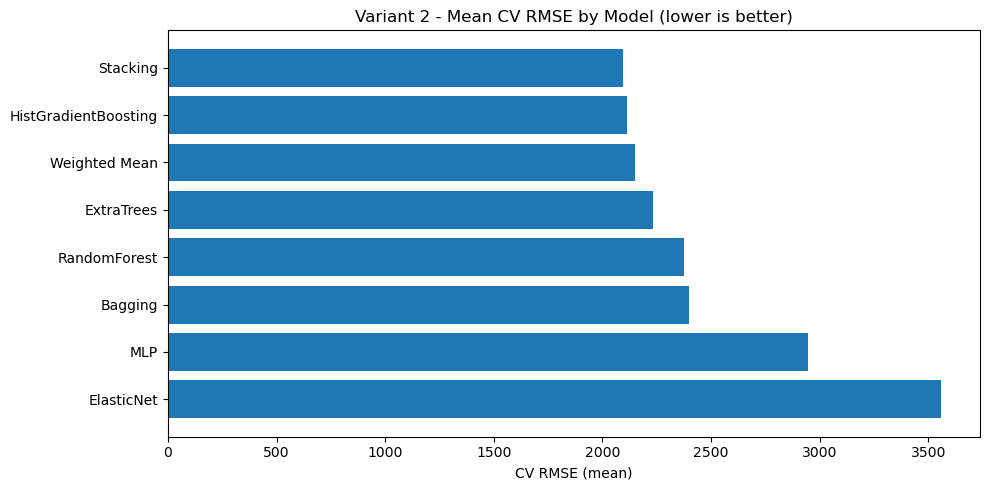

In [2]:
labels = df_sorted["model_name"]
values = df_sorted["rmse"]

plt.figure(figsize=(10, 5))
plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.xlabel("CV RMSE (mean)")
plt.title("Variant 2 - Mean CV RMSE by Model (lower is better)")
plt.tight_layout()
plt.show()

This plot ranks models by their mean cross-validated RMSE, providing a direct comparison of average out-of-sample accuracy across model families and variants. 

### 3.2. RMSE vs MAE scatter (consistency check)

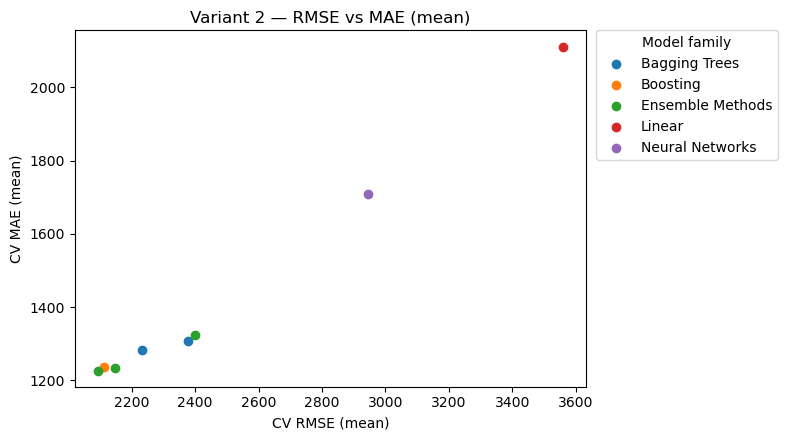

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# color automatically by model_family
for fam, g in df.groupby("model_family"):
    ax.scatter(g["rmse"], g["mae"], label=fam)

ax.set_xlabel("CV RMSE (mean)")
ax.set_ylabel("CV MAE (mean)")
ax.set_title("Variant 2 — RMSE vs MAE (mean)")

# put legend outside of the plot for readability 
ax.legend(title="Model family", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

This RMSE vs MAE scatter plot checks that models that reduce RMSE also reduce MAE, supporting that improvements reflect broad error reduction rather than isolated extreme cases.